<a href="https://colab.research.google.com/github/MiteshMahajan15-ui/PDS-Assignment/blob/main/Practical_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Batch:- B-1

Roll no.:-B-02

Name:- Mitesh Mahajan

       Assignment-7

Aim :-Implement and analyze various probability distributions in Python, including Binomial, Poisson, and Normal distributions.


Theory:-

## 1. Difference between Binomial, Poisson, and Normal Distributions

*   **Binomial Distribution:**
    *   **Nature:** Discrete.
    *   **Key Characteristics:** Models number of successes (k) in fixed trials (n) with constant probability (p).
    *   **Parameters:** `n` (number of trials), `p` (probability of success).
    *   **Example:** Number of heads in 10 coin flips.

*   **Poisson Distribution:**
    *   **Nature:** Discrete.
    *   **Key Characteristics:** Models number of rare events (k) in a fixed interval at a constant mean rate.
    *   **Parameters:** `λ` (average rate).
    *   **Example:** Number of calls per hour at a call center.

*   **Normal Distribution (Gaussian Distribution):**
    *   **Nature:** Continuous.
    *   **Key Characteristics:** Bell-shaped curve, data clusters symmetrically around central value.
    *   **Parameters:** `μ` (mean), `σ` (standard deviation).
    *   **Example:** Heights of adult humans.

## 2. Real-World Significance of Poisson Distribution

*   **Purpose:** The Poisson distribution is crucial for modeling random events that occur with a known average rate over a fixed period of time or space, especially when these events are rare and independent. It helps in understanding the probability of a certain number of events happening within a given interval.
*   **Applications:** It finds wide use in various fields:
    *   **Quality Control:** Estimating the number of defects in manufactured products per batch or per square meter.
    *   **Telecommunications:** Predicting the number of incoming calls to a call center per minute or per hour.
    *   **Healthcare/Epidemiology:** Modeling the incidence of rare diseases in a population or the number of emergency room admissions.
    *   **Finance:** Analyzing the number of trades or stock market fluctuations within a specific timeframe.
    *   **Biology:** Counting the number of mutations in a DNA strand or the number of bacteria in a culture.

## 3. Central Limit Theorem (CLT) & Normal Distribution

*   **Central Limit Theorem (CLT):** States that, regardless of the population distribution, the sampling distribution of the sample mean will tend towards a normal distribution as the sample size increases. This is particularly true for sufficiently large sample sizes (typically n > 30).
*   **Relation to Normal Distribution:** The CLT is fundamental to inferential statistics as it explains why the Normal distribution is so prevalent. It allows us to make inferences about population parameters (like the true mean) from sample data, even if the original population data itself is not normally distributed, by relying on the normality of the sampling distribution of the mean.

## 4. Why Normal Distribution is Widely Used in ML/Statistics

*   **CLT's Influence:** Due to the Central Limit Theorem, many statistical aggregates, such as sample means and sums, tend to be normally distributed, even if the underlying individual data points are not. This makes the normal distribution a natural fit for modeling these aggregates.
*   **Mathematical Tractability:** The normal distribution is well-understood mathematically. Its probability density function is easy to work with, and its properties (like symmetry and being fully characterized by just two parameters: mean and standard deviation) simplify many statistical calculations and derivations.
*   **Maximum Entropy Principle:** Among all distributions with a given mean and variance, the normal distribution has the maximum entropy. This means it makes the fewest assumptions about the data beyond its mean and variance, making it a robust default choice when only these two moments are known.
*   **Foundation for Algorithms:** Many foundational machine learning algorithms and statistical tests are based on the assumption of normality. For example, Linear Regression assumes normally distributed errors, Linear Discriminant Analysis (LDA) and Gaussian Naive Bayes explicitly model features using Gaussian distributions. Many hypothesis tests (t-tests, ANOVA) also rely on this assumption.
*   **Approximation for Other Distributions:** Under certain conditions, other distributions can be approximated by the normal distribution. For instance, the binomial and Poisson distributions approach a normal distribution as their parameters increase (large 'n' for binomial, large 'λ' for Poisson).

## 5. Skewness in Distributions

*   **Skewness Definition:** A measure of the asymmetry of a probability distribution about its mean.
*   **Types of Skewness:**
    *   **Zero Skewness (Symmetrical):** Mean = Median = Mode. Example: Normal distribution.
    *   **Positive Skewness (Right-Skewed):** Tail extends to the right. Mean > Median > Mode. Example: Income distribution.
    *   **Negative Skewness (Left-Skewed):** Tail extends to the left. Mean < Median < Mode. Example: Test scores (mostly high, few low).
*   **Distributions Exhibiting Skewness (examples):**
    *   **Binomial Distribution:** Symmetrical if `p = 0.5`, otherwise skewed.
    *   **Poisson Distribution:** Always positively skewed for finite `λ`; becomes more symmetrical as `λ` increases.

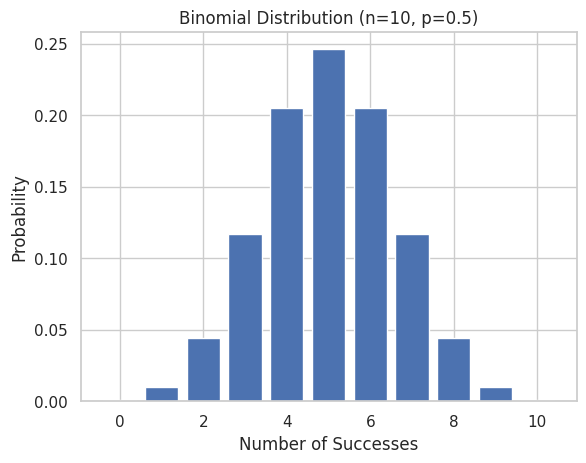

Binomial Skewness: -0.03250835363504422


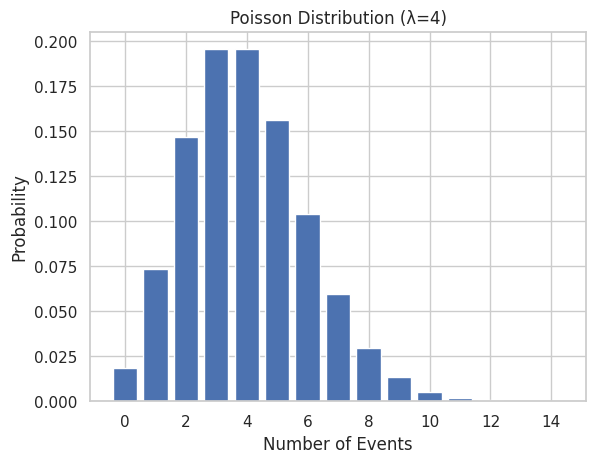

Poisson Skewness: 0.4943306678975715


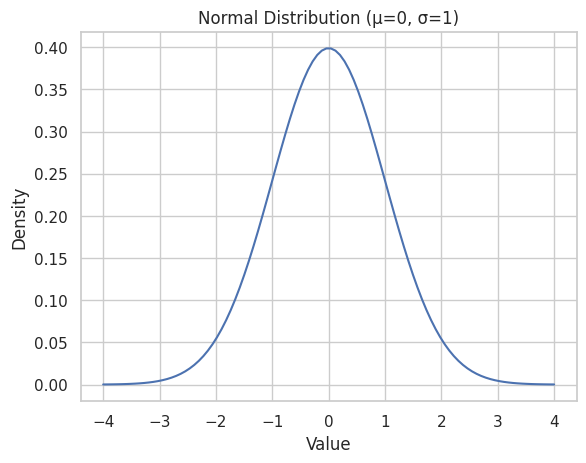

Normal Skewness: 0.01569901565046775


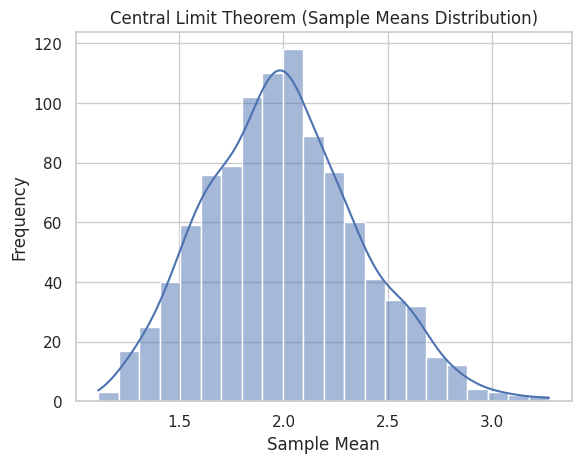

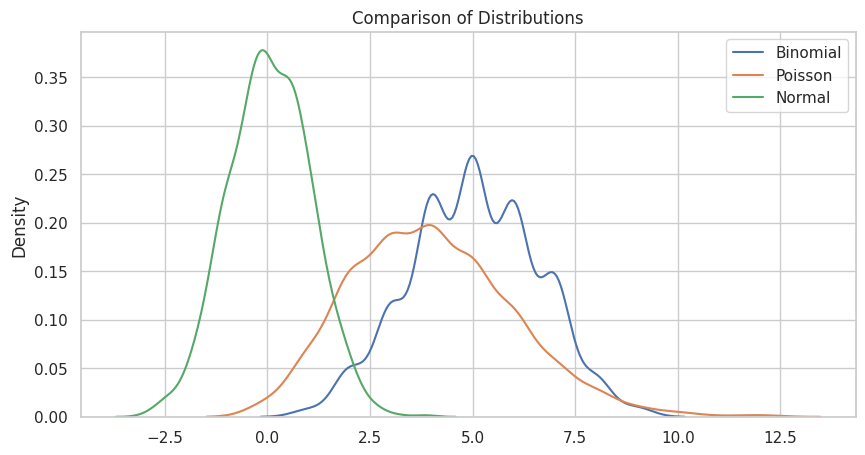

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom, poisson, norm, skew

# Set style
sns.set(style="whitegrid")

# -------------------------------
# 1. BINOMIAL DISTRIBUTION
# -------------------------------
n = 10          # number of trials
p = 0.5         # probability of success

x_binom = np.arange(0, n+1)
y_binom = binom.pmf(x_binom, n, p)

plt.figure()
plt.bar(x_binom, y_binom)
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.show()

# Generate sample and calculate skewness
binom_sample = binom.rvs(n, p, size=1000)
print("Binomial Skewness:", skew(binom_sample))


# -------------------------------
# 2. POISSON DISTRIBUTION
# -------------------------------
lam = 4   # average rate (λ)

x_poisson = np.arange(0, 15)
y_poisson = poisson.pmf(x_poisson, lam)

plt.figure()
plt.bar(x_poisson, y_poisson)
plt.title("Poisson Distribution (λ=4)")
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.show()

# Sample & skewness
poisson_sample = poisson.rvs(lam, size=1000)
print("Poisson Skewness:", skew(poisson_sample))


# -------------------------------
# 3. NORMAL DISTRIBUTION
# -------------------------------
mu = 0       # mean
sigma = 1    # standard deviation

x_norm = np.linspace(-4, 4, 100)
y_norm = norm.pdf(x_norm, mu, sigma)

plt.figure()
plt.plot(x_norm, y_norm)
plt.title("Normal Distribution (μ=0, σ=1)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# Sample & skewness
normal_sample = norm.rvs(mu, sigma, size=1000)
print("Normal Skewness:", skew(normal_sample))


# -------------------------------
# 4. CENTRAL LIMIT THEOREM DEMO
# -------------------------------
sample_means = []

for i in range(1000):
    sample = np.random.exponential(scale=2, size=30)  # non-normal data
    sample_means.append(np.mean(sample))

plt.figure()
sns.histplot(sample_means, kde=True)
plt.title("Central Limit Theorem (Sample Means Distribution)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()


# -------------------------------
# 5. COMPARISON PLOT
# -------------------------------
plt.figure(figsize=(10,5))

sns.kdeplot(binom_sample, label="Binomial")
sns.kdeplot(poisson_sample, label="Poisson")
sns.kdeplot(normal_sample, label="Normal")

plt.title("Comparison of Distributions")
plt.legend()
plt.show()

## Conclusion

This assignment provided an overview and practical implementation of three fundamental probability distributions: Binomial, Poisson, and Normal. We explored their definitions, key characteristics, real-world applications, and the concept of skewness.

We learned that the **Binomial distribution** is suitable for a fixed number of trials with two outcomes, like coin flips, while the **Poisson distribution** excels at modeling rare events over a fixed interval, such as the number of calls received by a call center. The **Normal distribution**, or Gaussian distribution, was highlighted as a continuous, symmetric, bell-shaped distribution, crucial due to the **Central Limit Theorem (CLT)**. The CLT demonstrates how sample means tend towards a normal distribution, regardless of the original population's distribution, making the Normal distribution indispensable in inferential statistics and machine learning.